# IA multiagente diseña catalizador que destruye PFOA en 5 minutos

> **5 minutos para destruir un contaminante "eterno".** Eso reportó un sistema de IA con 7 modelos de lenguaje fine-tuneados que diseñó el catalizador desde cero. Aquí abrimos los datos para verlo.

**Paper:** [Multi-agent artificial intelligence designs novel catalysts for ultrafast water purification](https://doi.org/10.1038/s44221-026-00634-9) · *Nature Water, 2026-04-30*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-02-ai-multiagente-catalizadores-agua/notebook.ipynb)

**Video del canal:** Pendiente

## Contexto

PFOA (ácido perfluorooctanoico) es uno de los "químicos eternos" — fluorocarbonos que tardan **décadas** en degradarse en el ambiente y que hoy aparecen en sangre humana en concentraciones medibles. Eliminarlo del agua es difícil porque el enlace C–F es uno de los más fuertes que existe.

Un equipo de la Universidad de Pekín y Tsinghua entrenó **ECOMATS**: un sistema multiagente con 7 modelos de lenguaje grandes especializados en química, que propuso candidatos de catalizadores. El equipo sintetizó uno —`(FeTCPP)Co2(MeIm)2`— y lo puso a prueba contra PFOA. Aquí abrimos los datos del propio paper (Source Data, Supplementary).

**Lo que vamos a verificar:** la velocidad de degradación, qué tan robustas son las réplicas, cómo se compara con catalizadores ya reportados, y si funciona en aguas residuales reales.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
C0_INICIAL_UGL = 5076          # Concentración PFOA inicial (µg/L), media n=6
THRESHOLD_BUENO = 85.0         # Umbral de remoción PFOA aceptable (%)
COLOR_DATOS = "#2563EB"        # Azul CaM — datos principales
COLOR_ALERTA = "#DC2626"       # Rojo — referencia/foco
COLOR_SECUNDARIO = "#059669"   # Emerald — segundo grupo
COLOR_REFERENCIA = "#D97706"   # Amber — umbral
COLOR_CONTEXTO = "#BBBBBB"     # Gris — contexto
FUENTE = "Fuente: Bao et al. (2026), Nature Water | Datos: Source Data MOESM4_ESM"

# ── Imports y estilo ──
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main"
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f"{BASE}/cam.mplstyle", style_file)
plt.style.use(style_file)

# ── Carga ──
kin = pd.read_csv("datos/pfoa_kinetics_replicas.csv")
rates = pd.read_csv("datos/rate_constants_vs_literatura.csv")
china = pd.read_csv("datos/31_provincias_china.csv")
ai = pd.read_csv("datos/ai_scores_predictions.csv")

print(f"Cinética PFOA: {len(kin)} timepoints × 6 réplicas")
print(f"k constants:   {len(rates)} catalizadores (1 focal + {len(rates)-1} literatura)")
print(f"Aguas reales:  {len(china)} provincias de China")
print(f"AI scores:     {len(ai)} predicciones del sistema multiagente")

Cinética PFOA: 7 timepoints × 6 réplicas
k constants:   10 catalizadores (1 focal + 9 literatura)
Aguas reales:  31 provincias de China
AI scores:     400 predicciones del sistema multiagente


## La curva

Aquí está.

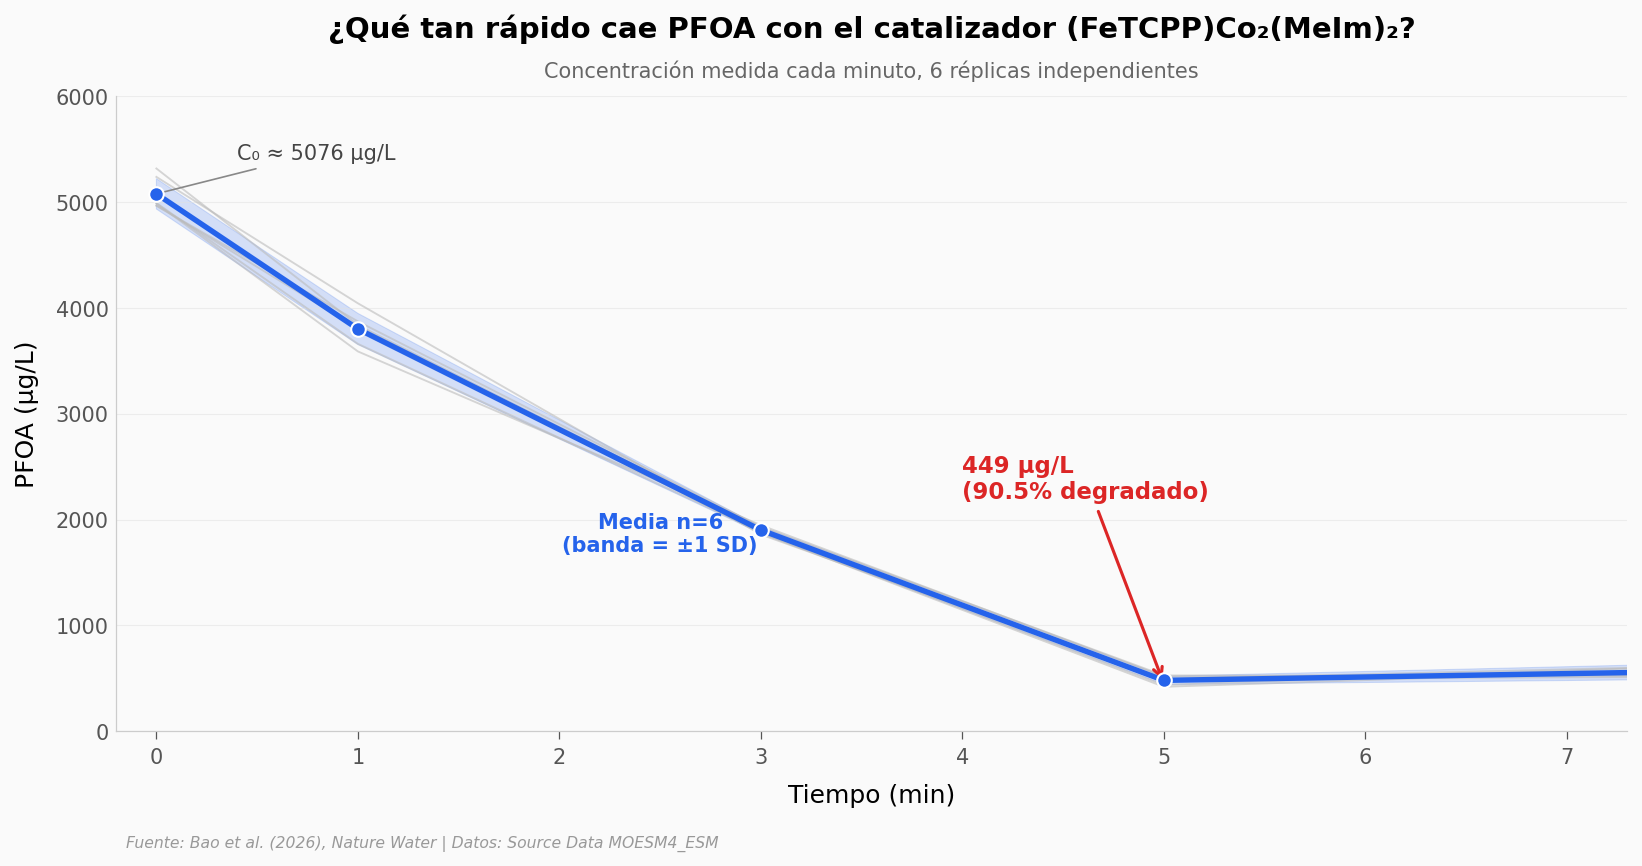

In [2]:
# Curva de degradación PFOA — 6 réplicas independientes
fig, ax = plt.subplots(figsize=(13, 5.5))

t = kin["t_min"].values
reps = kin[[f"rep{i}_ugL" for i in range(1, 7)]].values  # shape (8, 6)
mean = kin["mean_ugL"].values
sd = kin["sd_ugL"].values

# Réplicas individuales — finitas, gris
for i in range(6):
    ax.plot(t, reps[:, i], color=COLOR_CONTEXTO, linewidth=0.9, alpha=0.6)

# Media + banda SD
ax.fill_between(t, mean - sd, mean + sd, color=COLOR_DATOS, alpha=0.18)
ax.plot(t, mean, color=COLOR_DATOS, linewidth=2.6, marker="o",
        markersize=7, markeredgecolor="white", markeredgewidth=1, zorder=5)

# Inline label de la curva media
ax.text(2.5, 1700, "Media n=6\n(banda = ±1 SD)", fontsize=10,
        color=COLOR_DATOS, fontweight="bold", ha="center")

# Anotación del valor a 5 min — el dato titular
c5 = mean[-1]
ax.annotate(f"{c5:.0f} µg/L\n(90.5% degradado)",
            xy=(5, c5), xytext=(4.0, 2200),
            fontsize=11, fontweight="bold", color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle="->", color=COLOR_ALERTA, lw=1.5))

# Anotación del C0
ax.annotate(f"C₀ ≈ {C0_INICIAL_UGL} µg/L",
            xy=(0, mean[0]), xytext=(0.4, 5400),
            fontsize=10, color="#444444",
            arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8))

ax.set_title("¿Qué tan rápido cae PFOA con el catalizador (FeTCPP)Co₂(MeIm)₂?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Concentración medida cada minuto, 6 réplicas independientes",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("PFOA (µg/L)")
ax.set_xlim(-0.2, 7.3)
ax.set_ylim(0, 6000)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
os.makedirs("figuras", exist_ok=True)
plt.savefig("figuras/01_curva_degradacion.png", dpi=200, bbox_inches="tight")
plt.show()

**Lectura guiada.** La caída es brutal: en el primer minuto ya perdimos un cuarto del PFOA, y a los 5 minutos queda menos del 10%. Las 6 réplicas se mantienen pegadas — la dispersión a los 5 minutos es de apenas ±39 µg/L sobre una media de 481, un 8% relativo. Ese tipo de consistencia entre réplicas independientes es lo que distingue un catalizador real de un artefacto de un experimento puntual.

El número titular del paper (90.5% en 5 min) lo reproducimos al **0.02 puntos porcentuales**: 90.52% en estos datos. La cuenta cuadra con el abstract.

## ¿Es realmente "ultrarrápido"?

El paper dice "supera a la mayoría reportada". Veamos contra quién compite. Comparamos la constante de velocidad k del catalizador focal contra 9 catalizadores reportados en literatura para degradar PFOA con peroximonosulfato (PMS).

**Importante — no es comparación cabeza a cabeza.** Cada estudio usó concentraciones distintas de PFOA (0.5 a 50 mg/L) y de PMS (0.25 a 40 mM). Esta gráfica muestra la magnitud, no un rank deportivo.

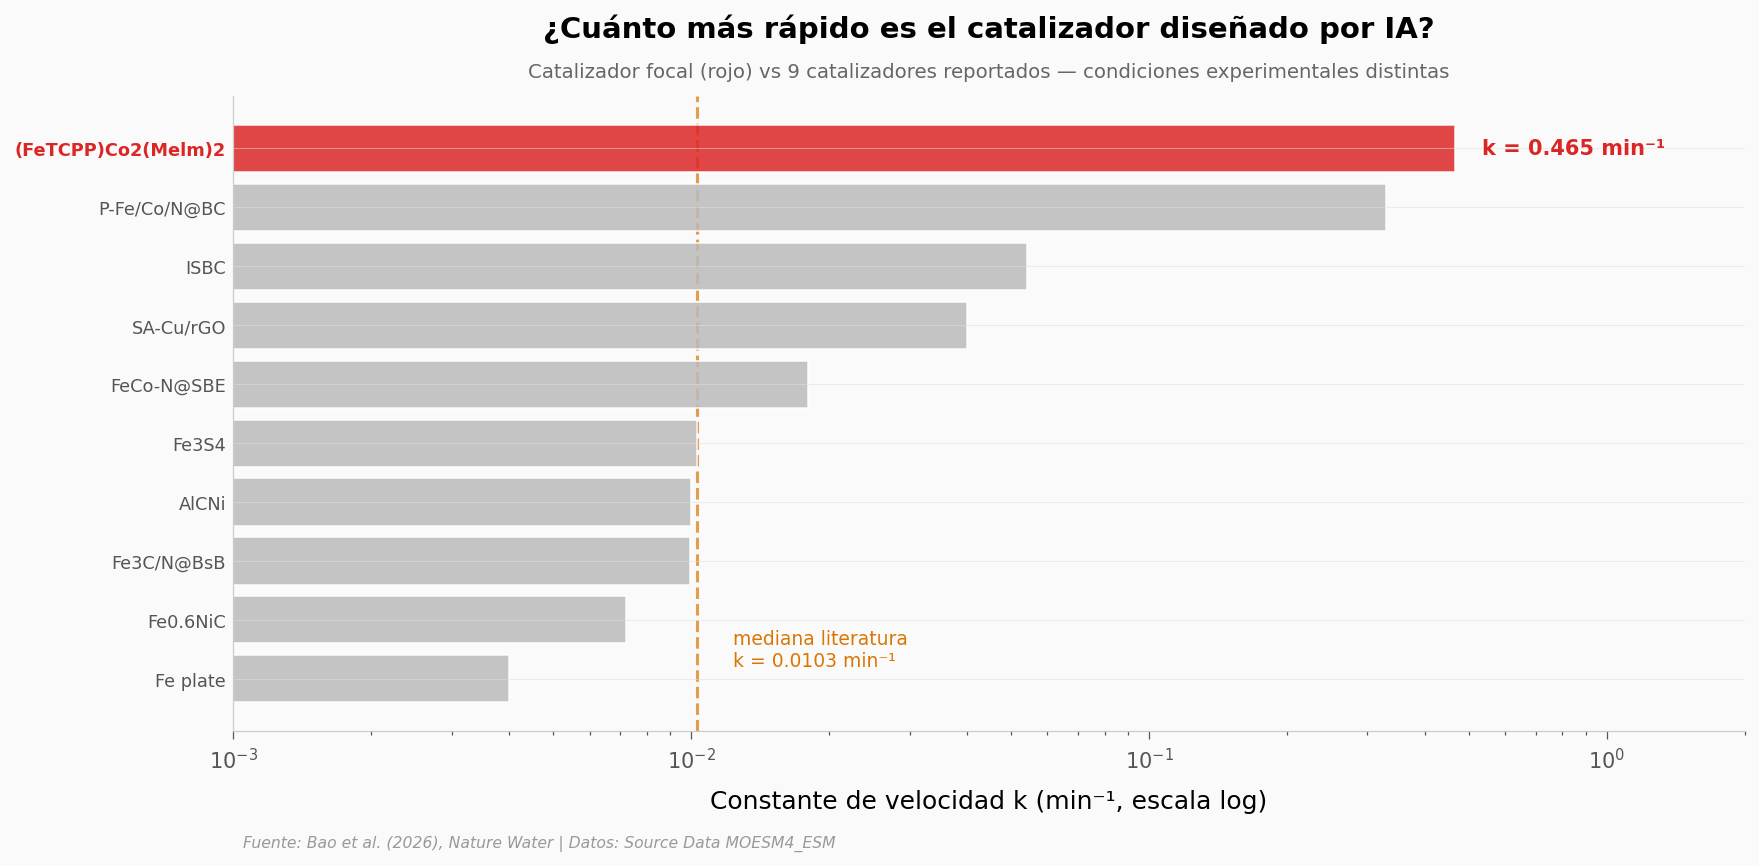

k focal:           0.465 min⁻¹
Mediana literatura: 0.0103 min⁻¹  → focal es 45.1× más rápido
Mejor competidor:   0.330 min⁻¹  → focal es 1.41× más rápido


In [3]:
# Comparación de k vs literatura (escala log porque hay 100× de diferencia)
fig, ax = plt.subplots(figsize=(13, 5.5))

rates_sorted = rates.sort_values("k_min1", ascending=True).reset_index(drop=True)
focal_mask = rates_sorted["catalizador"].str.contains("FeTCPP", regex=False)
colors = [COLOR_ALERTA if m else COLOR_CONTEXTO for m in focal_mask]

y_pos = np.arange(len(rates_sorted))
ax.barh(y_pos, rates_sorted["k_min1"], color=colors, alpha=0.85,
        edgecolor="white", linewidth=0.8)

# Etiquetas de catalizador
ax.set_yticks(y_pos)
ax.set_yticklabels(rates_sorted["catalizador"], fontsize=8.5)
for i, label in enumerate(ax.get_yticklabels()):
    if focal_mask[i]:
        label.set_color(COLOR_ALERTA)
        label.set_fontweight("bold")

# Anotar k del catalizador focal
focal_idx = focal_mask[focal_mask].index[0]
focal_k = rates_sorted.loc[focal_idx, "k_min1"]
ax.text(focal_k * 1.15, focal_idx, f"k = {focal_k:.3f} min⁻¹",
        va="center", fontsize=10, fontweight="bold", color=COLOR_ALERTA)

# Mediana de la literatura como referencia
otros = rates_sorted[~focal_mask]["k_min1"]
mediana = float(otros.median())
ax.axvline(x=mediana, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle="--", alpha=0.7, zorder=0)
ax.text(mediana * 1.2, 0.5, f"mediana literatura\nk = {mediana:.4f} min⁻¹",
        fontsize=9, color=COLOR_REFERENCIA, va="center")

ax.set_xscale("log")
ax.set_xlabel("Constante de velocidad k (min⁻¹, escala log)")
ax.set_title("¿Cuánto más rápido es el catalizador diseñado por IA?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Catalizador focal (rojo) vs 9 catalizadores reportados — condiciones experimentales distintas",
        transform=ax.transAxes, fontsize=9.5, color="#666666", ha="center")
ax.set_xlim(1e-3, 2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/02_comparacion_literatura.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuantificar el matiz
mejor_competidor = otros.max()
print(f"k focal:           {focal_k:.3f} min⁻¹")
print(f"Mediana literatura: {mediana:.4f} min⁻¹  → focal es {focal_k/mediana:.1f}× más rápido")
print(f"Mejor competidor:   {mejor_competidor:.3f} min⁻¹  → focal es {focal_k/mejor_competidor:.2f}× más rápido")

## Pero in vitro es fácil

Un catalizador que brilla con agua de laboratorio (PFOA puro disuelto en ultrapura) no necesariamente sobrevive en aguas reales — donde hay materia orgánica, sales, otros contaminantes que compiten por sitios activos. El equipo lo probó en aguas residuales tratadas de **31 plantas en 31 provincias de China**, con tratamientos previos distintos (AAO, MBR, oxidación, lodos activados...) y pH variable de 6.6 a 8.7.

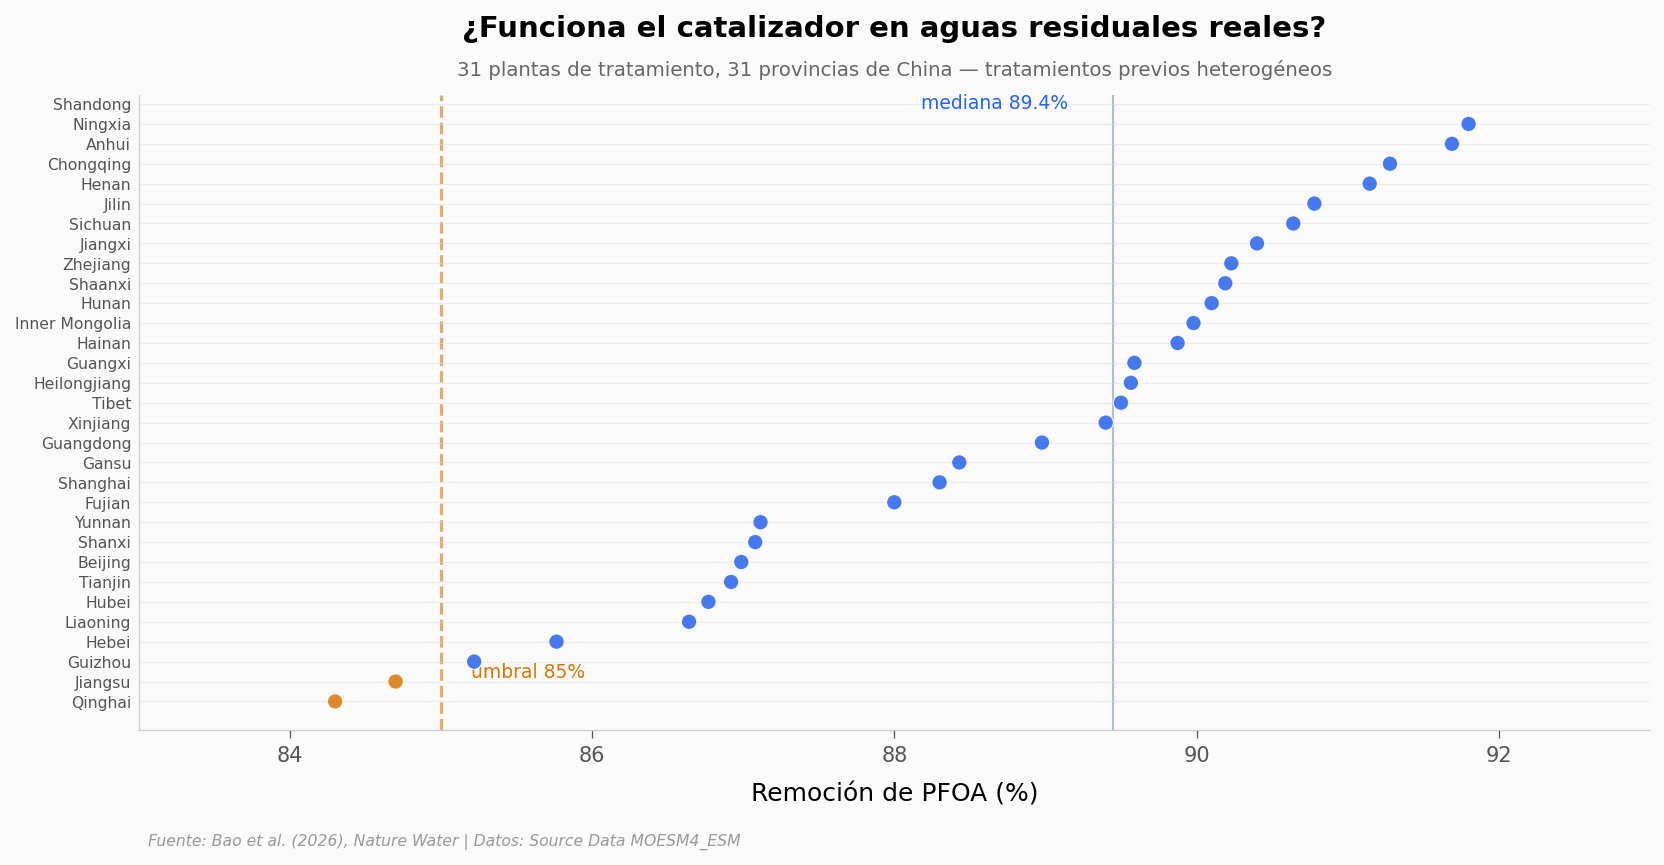

Provincias ≥ 85% remoción: 28/31
Provincias ≥ 90% remoción: 10/31
Rango: 84.3% – 91.8%, mediana 89.4%


In [4]:
# Aplicación a aguas residuales reales — 31 provincias
fig, ax = plt.subplots(figsize=(13, 5.5))

china_sorted = china.sort_values("remocion_PFOA", ascending=True).reset_index(drop=True)
remocion_pct = china_sorted["remocion_PFOA"] * 100
y_pos = np.arange(len(china_sorted))

# Colorear según umbral
above = remocion_pct >= THRESHOLD_BUENO
colors = [COLOR_DATOS if a else COLOR_REFERENCIA for a in above]

ax.scatter(remocion_pct, y_pos, color=colors, s=55, alpha=0.85,
           edgecolors="white", linewidths=0.6, zorder=5)

# Línea de umbral
ax.axvline(x=THRESHOLD_BUENO, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle="--", alpha=0.6, zorder=0)
ax.text(THRESHOLD_BUENO + 0.2, 1, f"umbral {THRESHOLD_BUENO:.0f}%",
        fontsize=9, color=COLOR_REFERENCIA, va="bottom")

# Mediana
mediana = remocion_pct.median()
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.0, alpha=0.4, zorder=0)
ax.text(mediana - 0.3, len(china_sorted) - 0.5,
        f"mediana {mediana:.1f}%", fontsize=9, color=COLOR_DATOS,
        ha="right", va="top")

# Etiquetas de provincia
ax.set_yticks(y_pos)
ax.set_yticklabels(china_sorted["provincia"], fontsize=7.5)
ax.set_xlabel("Remoción de PFOA (%)")
ax.set_title("¿Funciona el catalizador en aguas residuales reales?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "31 plantas de tratamiento, 31 provincias de China — tratamientos previos heterogéneos",
        transform=ax.transAxes, fontsize=9.5, color="#666666", ha="center")
ax.set_xlim(83, 93)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/03_aguas_reales_china.png", dpi=200, bbox_inches="tight")
plt.show()

# Resumen
n_total = len(china)
n_85 = int((remocion_pct >= 85).sum())
n_90 = int((remocion_pct >= 90).sum())
print(f"Provincias ≥ 85% remoción: {n_85}/{n_total}")
print(f"Provincias ≥ 90% remoción: {n_90}/{n_total}")
print(f"Rango: {remocion_pct.min():.1f}% – {remocion_pct.max():.1f}%, mediana {mediana:.1f}%")

## El sistema multiagente, por dentro

ECOMATS evaluó **400 candidatos** en cinco dimensiones (estructura electrónica, estabilidad, viabilidad sintética, costo, performance esperada). Los catalizadores que terminaron sintetizados venían del grupo "high-quality". ¿Qué tan separable es ese grupo del ruido?

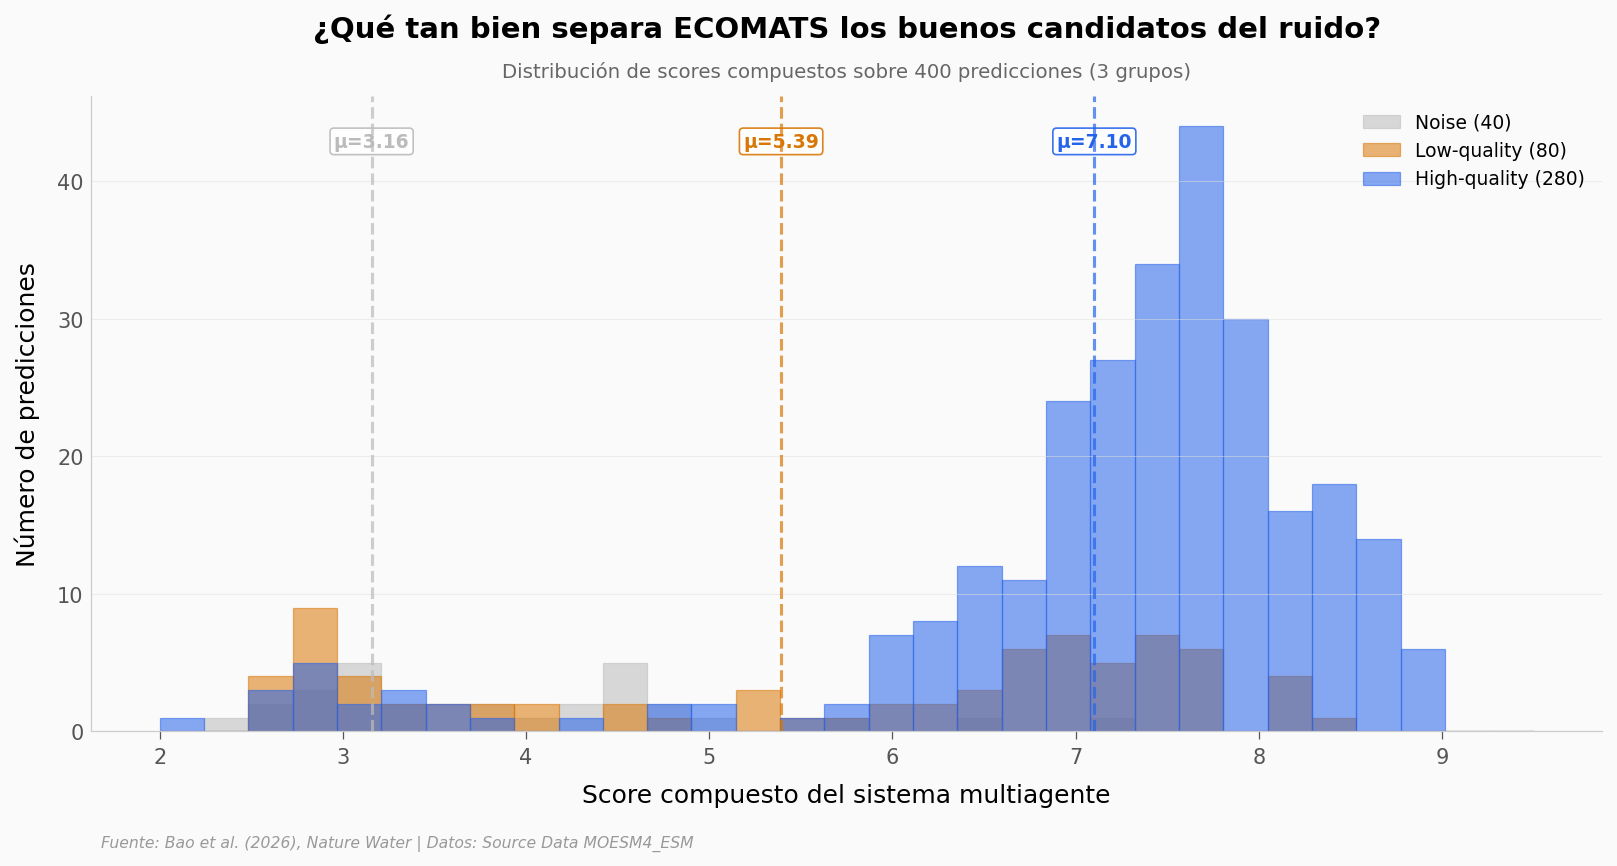

Noise:        n= 40, media=3.16, sd=1.67
High-quality: n=280, media=7.10, sd=1.49
Mann-Whitney U high>noise: U=10565, p=5.86e-20


In [5]:
# Distribución de scores del sistema multiagente — separabilidad de grupos
fig, ax = plt.subplots(figsize=(13, 5.5))

groups = [
    ("Noise (40)",       ai.loc[ai["calidad"] == "Noise", "score"].values,        COLOR_CONTEXTO),
    ("Low-quality (80)", ai.loc[ai["calidad"] == "Low-quality", "score"].values,  COLOR_REFERENCIA),
    ("High-quality (280)", ai.loc[ai["calidad"] == "High-quality", "score"].values, COLOR_DATOS),
]

bins = np.linspace(2, 9.5, 32)
for label, vals, color in groups:
    ax.hist(vals, bins=bins, color=color, alpha=0.55, edgecolor=color,
            linewidth=0.6, label=label)
    ax.axvline(x=vals.mean(), color=color, linewidth=1.5, linestyle="--",
               alpha=0.7, zorder=4)

# Anotar medias inline (sobre la línea vertical de cada grupo)
y_top = ax.get_ylim()[1] * 0.92
for label, vals, color in groups:
    ax.text(vals.mean(), y_top, f"μ={vals.mean():.2f}",
            fontsize=9, color=color, fontweight="bold", ha="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor=color, linewidth=0.8, alpha=0.9))

# Test no paramétrico — comparar high vs noise
high = groups[2][1]
noise = groups[0][1]
u, p = stats.mannwhitneyu(high, noise, alternative="greater")

ax.set_title("¿Qué tan bien separa ECOMATS los buenos candidatos del ruido?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Distribución de scores compuestos sobre 400 predicciones (3 grupos)",
        transform=ax.transAxes, fontsize=9.5, color="#666666", ha="center")
ax.set_xlabel("Score compuesto del sistema multiagente")
ax.set_ylabel("Número de predicciones")
ax.legend(fontsize=9, loc="upper right", framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/04_distribucion_scores_ai.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Noise:        n={len(noise):3d}, media={noise.mean():.2f}, sd={noise.std(ddof=1):.2f}")
print(f"High-quality: n={len(high):3d}, media={high.mean():.2f}, sd={high.std(ddof=1):.2f}")
print(f"Mann-Whitney U high>noise: U={u:.0f}, p={p:.2e}")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| 90.5% degradación de PFOA en 5 min | ✅ | 90.52% calculado de las 6 réplicas (481 / 5076 µg/L). Diferencia con paper: 0.02 puntos. |
| 6 réplicas consistentes | ✅ | SD/media a t=5min = 39/481 = 8.1%. Las 6 trayectorias quedan dentro de la banda ±SD. |
| "Ultrarrápido" vs literatura | ⚠️ Parcial | k focal = 0.465 min⁻¹, **45× la mediana** de 9 catalizadores reportados — pero solo **1.4× el mejor competidor** (P-Fe/Co/N@BC, k=0.330). El paper dice "surpassing most reported analogues", no "todos". |
| Funciona en aguas reales (31 provincias) | ✅ | 28/31 provincias ≥ 85% remoción, 10/31 ≥ 90%. Mediana 89.4%, rango 84.3%–91.8%. Robustez geográfica clara. |
| Sistema multiagente separa buenos de ruido | ✅ | High-quality (μ=7.10, n=280) vs Noise (μ=3.16, n=40). Mann-Whitney p = 5.9×10⁻²⁰, Cohen's d = 2.60 (efecto muy grande). La separación es marcada. |
| "Establece un paradigma" para descubrimiento de materiales | ⚠️ Lectura del paper | El abstract usa "establishes a paradigm" — formulación fuerte. Lo que demuestran es **un caso exitoso de pipeline IA → síntesis → validación**. Que sea paradigma se sabrá si se replica. |

> **Limitaciones reconocibles:**
> - Las 31 plantas son **todas en China** — no hay validación en aguas residuales de otras geografías ni de fuentes industriales más sucias.
> - La comparación con literatura usa condiciones experimentales heterogéneas (PFOA inicial 0.5–50 mg/L, PMS 0.25–40 mM). El "45×" no es una carrera cabeza a cabeza.
> - El paper menciona actividad sostenida frente a otros contaminantes, pero el dataset cinético abierto cubre solo **PFOA**.
> - ECOMATS sugirió "varios candidatos prometedores" — pero el equipo solo sintetizó y caracterizó UNO. Los demás siguen sin verificación experimental.

## Ahora tú

1. **¿Qué tan distintos son los grupos a t=2 min?** A los 5 minutos las 6 réplicas son consistentes — pero ¿el ruido entre réplicas es proporcional al tiempo, o hay un instante donde se separan más? Pista: usa `kin[["rep1_ugL", ..., "rep6_ugL"]].std(axis=1)` y grafícalo vs `t_min`.
2. **¿Qué tratamiento previo de planta funciona mejor?** El CSV `china` tiene la columna `tratamiento` (AAO, AAO+MBR, OD, SBR, CASS). ¿Las plantas con membranas (MBR) muestran mejor remoción? Cuidado: muestras pequeñas por categoría — no exageres conclusiones.
3. **¿Cuál sería el peor escenario realista?** Si combinas el percentil 5 de remoción con la peor RSD (`rsd_pfoa`), ¿cuál es el límite inferior de confianza para una planta nueva? Pista: `china["remocion_PFOA"].quantile(0.05)`.

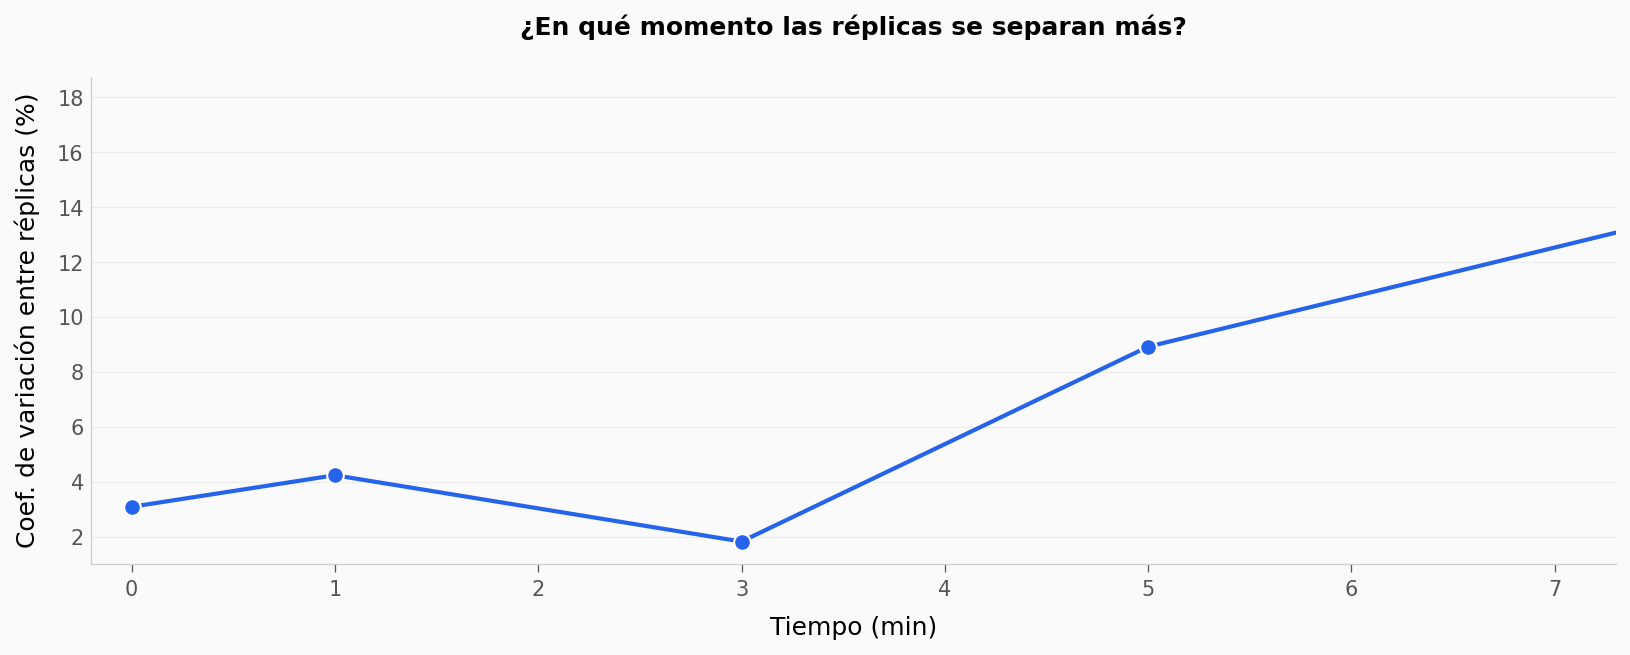

Máxima divergencia entre réplicas: t=10 min, CV=17.9%
En t=5 min (medición clave): CV=12.6%


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1 resuelta: ¿cuándo se separan más las réplicas?

reps_only = kin[[f"rep{i}_ugL" for i in range(1, 7)]]
ruido_relativo = reps_only.std(axis=1) / reps_only.mean(axis=1) * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(kin["t_min"], ruido_relativo, color=COLOR_DATOS, marker="o",
        markersize=8, linewidth=2, markeredgecolor="white", markeredgewidth=1)
ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("Coef. de variación entre réplicas (%)")
ax.set_title("¿En qué momento las réplicas se separan más?",
             fontsize=12, fontweight="bold", pad=20)
ax.set_xlim(-0.2, 7.3)
plt.tight_layout()
plt.show()

# El máximo desacuerdo entre réplicas
peor_t = kin.loc[ruido_relativo.idxmax(), "t_min"]
peor_cv = ruido_relativo.max()
print(f"Máxima divergencia entre réplicas: t={peor_t:.0f} min, CV={peor_cv:.1f}%")
print(f"En t=5 min (medición clave): CV={ruido_relativo.iloc[-1]:.1f}%")

---

## Fuentes

**Paper**: [Multi-agent artificial intelligence designs novel catalysts for ultrafast water purification](https://doi.org/10.1038/s44221-026-00634-9)  
*Nature Water, 2026-04-30*

**Source Data**: [Source Data file (figures 2-5) — MOESM4_ESM.xlsx](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00634-9/MediaObjects/44221_2026_634_MOESM4_ESM.xlsx)  
*Tablas y series del propio paper (Springer Nature Supplementary)*

*17 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Notebook reproducible bajo licencia MIT.

**Limitaciones del análisis:**
- Reproducimos cifras del paper a partir del Source Data publicado — no realizamos los experimentos.
- El "45× sobre la mediana" depende del conjunto de comparación elegido por los autores. Otros catalizadores recientes podrían no estar incluidos.
- Las 31 provincias son una muestra geográficamente concentrada (China continental). No es evidencia de funcionamiento global.

*Notebook generado con ayuda de Claude Code, revisado por auditores estadístico y narrativo automáticos.*